# Structural Analysis — Sample-Size Sensitivity

Reproduces sensitivity results presented in **Appendix C** of the paper — Wasserstein significance and separability as functions of the response-set size N (Figure 7).  
Same script is also used to prepare Fig. 10 on CoQA.

---

## Setup

In [1]:
import os
import pathlib

# allow execution from either the repo root or code/
ROOT = pathlib.Path.cwd()
if ROOT.name == "code":
    os.chdir(ROOT.parent)

os.environ["OPENBLAS_NUM_THREADS"] = "4"


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import aporia as ap


In [3]:
# ---------------------------------------------------------------
# Load dataset + model metadata from a TOML config.
# ---------------------------------------------------------------
CONFIG_PATH = "config/socrates.toml"

cfg = ap.load_config(CONFIG_PATH)

# expose names downstream cells still use
model_names           = cfg.model_names
figures_dir           = cfg.cache.fig_dir
model_latextags       = cfg.model_latextags
best_reg_lambda       = cfg.experiment.best_lambda
cache_dir             = cfg.cache.root


In [4]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = ap.matplotlib_latex_preamble(cfg)


## Data

In [5]:
df = ap.load_dataframe(cfg)
model_order, model_rank = ap.build_model_size_order(cfg)

## Structural ablation: separability and significance vs. response count N

We ablate the structural analysis over the number of responses sampled per prompt $N$.
For each $(\text{model}, \text{prompt})$ pair and each $N$:

1. Draw a **random subsample of $N$ responses** (without replacement, preserving the
   natural class ratio of the prompt).
2. Accept the subsample only if it contains $\geq 2$ genuine **and** $\geq 2$ hallucinated
   responses — otherwise discard this iteration.
3. On the accepted subsample compute:
   - $W_{\text{obs}} = W(D_{GG},\,D_{HH})$ and a permutation null → $p$-value.
   - Separability ratio $\rho = \bar D_{GH} / \tfrac{1}{2}(\bar D_{GG}+\bar D_{HH})$
     in both the **original SBERT space** and the **Fisher-projected 1-D space**.
4. Repeat `n_iter` times and average.

The fixed denominator for all percentages is the number of $(\text{model},\text{prompt})$
pairs that are **valid at any N** — i.e. those that passed the $n_G \geq 5$, $n_H \geq 5$
filter in the full structural analysis (`valid_geom=True` in `results_df`).
This makes the percentages directly comparable across rows.

In [6]:
# Absolute sample sizes to sweep.
N_values = [10, 15, 20, 30, 50, 75, 100, 150]

N_PERMUTATIONS = 200   # permutations per accepted subsample
N_ITER         = 20    # repeated subsamples per (prompt, N)
ALPHA          = 0.05  # significance threshold

SA_CACHE_DIR = f"{cfg.cache.root}/structural_ablation_v3"
os.makedirs(SA_CACHE_DIR, exist_ok=True)


## Experiment

In [7]:
from scipy.stats import mannwhitneyu

In [8]:
prompt_ids_by_model = ap.prompt_ids_by_model(df, cfg)

all_frames = []

for mid, pids in tqdm(prompt_ids_by_model.items(), desc="Model"):
    for pid in tqdm(pids, desc="Prompt", leave=False):

        cache_path = os.path.join(
            SA_CACHE_DIR, f"model={mid}__prompt={pid}.parquet"
        )

        if os.path.exists(cache_path):
            all_frames.append(pd.read_parquet(cache_path))
            continue

        res = ap.run_structural_ablation_for_prompt(
            df, mid, pid, cfg,
            N_values       = N_values,
            lambda_reg     = best_reg_lambda,
            n_iter         = N_ITER,
            n_permutations = N_PERMUTATIONS,
        )

        if res is None or len(res) == 0:
            continue

        res.to_parquet(cache_path, index=False)
        all_frames.append(res)

results_sa = pd.concat(all_frames, ignore_index=True)
print(f"Total rows: {len(results_sa):,}")
print(results_sa.dtypes)


Model:   0%|          | 0/10 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

...

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Prompt:   0%|          | 0/200 [00:00<?, ?it/s]

Total rows: 254,997
model_id         int64
prompt_id        int64
N                int64
n_genuine        int64
n_hall           int64
iter_id          int64
W_obs          float64
W_null_mean    float64
W_null_std     float64
p_wass         float64
sig_wass          bool
p_mw           float64
sig_mw            bool
sep            float64
sep_z          float64
dtype: object


## Fixed denominator

All percentages below are expressed over the **total number of valid
$(\text{model}, \text{prompt})$ pairs** — those with `valid_geom=True` in the
full structural analysis.  This number is independent of $N$ and is the
natural "whole dataset" baseline.

In [9]:
# Load the full structural analysis (uses cache — no recomputation).
# n_permutations=0 skips the null-model loop; we only need geom flags + counts.
results_df_full, _, _ = ap.run_structural_analysis(
    df, cfg,
    n_permutations  = 0,
    use_cache       = True,
    overwrite_cache = False,
)

# Per-N denominator: valid_geom prompts that also have n_total >= N.
base = results_df_full[results_df_full["valid_geom"]]
N_TOTAL_VALID_ALL = len(base)

N_DENOM = {
    N: int((base["n_total"] >= N).sum())
    for N in N_values
}

print(f"Reference (all valid_geom pairs): {N_TOTAL_VALID_ALL}")
print()
print(f"  {'N':>4}  {'n_testable':>10}  {'% of valid_geom':>16}")
for N, d in N_DENOM.items():
    print(f"  {N:>4}  {d:>10}  {d/N_TOTAL_VALID_ALL*100:>15.1f}%")


Cache correctly loaded.
Reference (all valid_geom pairs): 1777

     N  n_testable   % of valid_geom
    10        1777            100.0%
    15        1777            100.0%
    20        1777            100.0%
    30        1777            100.0%
    50        1777            100.0%
    75        1777            100.0%
   100        1777            100.0%
   150         951             53.5%


## Aggregate results

In [10]:
# Step 1: average over iterations → one value per (model, prompt, N)
prompt_level = (
    results_sa
    .groupby(["model_id", "prompt_id", "N"])
    .agg(
        # Wasserstein significance
        sig_wass_rate  = ("sig_wass",     "mean"),
        p_wass_mean    = ("p_wass",       "mean"),
        W_obs_mean     = ("W_obs",        "mean"),
        W_null_mean    = ("W_null_mean",  "mean"),
        # Mann-Whitney significance
        sig_mw_rate    = ("sig_mw",       "mean"),
        p_mw_mean      = ("p_mw",         "mean"),
        # separability
        sep_mean       = ("sep",          "mean"),
        sep_z_mean     = ("sep_z",        "mean"),
        # bookkeeping
        n_iters        = ("iter_id",      "count"),
        n_genuine_mean = ("n_genuine",    "mean"),
        n_hall_mean    = ("n_hall",       "mean"),
    )
    .reset_index()
)

# A prompt "passes" if significant in the majority of iters
prompt_level["sig_wass_majority"] = prompt_level["sig_wass_rate"] > 0.5
prompt_level["sig_mw_majority"]   = prompt_level["sig_mw_rate"]   > 0.5
prompt_level["above_null_mean"] = prompt_level["W_obs_mean"] > prompt_level["W_null_mean"]

# Step 2: aggregate over prompts using per-N denominator N_DENOM[N]

global_frac = (
    prompt_level
    .groupby("N")
    .apply(lambda grp: ap.global_stats(grp, N_DENOM.get(grp.name, N_TOTAL_VALID_ALL)))
    .reset_index()
)

model_frac = (
    prompt_level
    .groupby(["model_id", "N"])
    .apply(lambda g: pd.Series({
        "frac_sig_wass":    g["sig_wass_majority"].mean(),
        "frac_sig_mw":      g["sig_mw_majority"].mean(),
        "frac_above_model": g["above_null_mean"].mean(),
        "sep_mean":         g["sep_mean"].mean(),
        "sep_z_mean":       g["sep_z_mean"].mean(),
    }))
    .reset_index()
)

cols = ["N","n_denom","n_tested","n_sig_wass","frac_sig_wass","n_sig_mw","frac_sig_mw", "1-p_wass_mean", "frac_above_fixed"]
print(global_frac[cols].to_string(index=False))
print("\nNumbers for rebuttal [XXX] placeholders (Mann-Whitney, fixed denominator):")
for _, row in global_frac.iterrows():
    print(f"  N={int(row['N']):3d}: "
          f"Wass {row['frac_sig_wass']*100:4.1f}%  "
          f"MW {row['frac_sig_mw']*100:4.1f}%  "
          f"({int(row['n_sig_mw']):4d}/{int(row['n_denom']):4d})  "
          f"W>W0 {100*row['frac_above_fixed']:4.1f}%")
    
print('\n\n')
cols = ["N","n_denom","n_tested","n_sig_wass","frac_sig_wass","n_sig_mw","frac_sig_mw", "1-p_wass_mean", "frac_above_fixed"]
print(global_frac[cols].to_string(index=False))
print("\nNumbers for rebuttal [XXX] placeholders (Mann-Whitney, fixed denominator):")
for _, row in global_frac.iterrows():
    print(f"|{int(row['N']):3d}|"
          f"{row['frac_sig_wass']*100:4.1f}|"
          f"{row['frac_sig_mw']*100:4.1f}|"
          f"{int(row['n_sig_mw']):4d}/{int(row['n_denom']):4d}|"
          f"{100*row['frac_above_fixed']:4.1f}|")

  N  n_denom  n_tested  n_sig_wass  frac_sig_wass  n_sig_mw  frac_sig_mw  1-p_wass_mean  frac_above_fixed
 10   1777.0    1740.0       129.0       0.072594     109.0     0.061339       0.637450          0.791221
 15   1777.0    1757.0       280.0       0.157569     336.0     0.189083       0.675542          0.818233
 20   1777.0    1774.0       378.0       0.212718     523.0     0.294316       0.700394          0.831739
 30   1777.0    1777.0       547.0       0.307822     758.0     0.426562       0.735464          0.839617
 50   1777.0    1777.0       789.0       0.444007    1010.0     0.568374       0.781009          0.861002
 75   1777.0    1777.0       939.0       0.528419    1221.0     0.687113       0.819535          0.865504
100   1777.0    1777.0      1036.0       0.583005    1324.0     0.745076       0.843580          0.873382
150    951.0     951.0       622.0       0.654048     796.0     0.837014       0.880222          0.881178

Numbers for rebuttal [XXX] placeholders (Mann

## Fraction of significant prompts vs N -- Fig. 7 (and 10) 

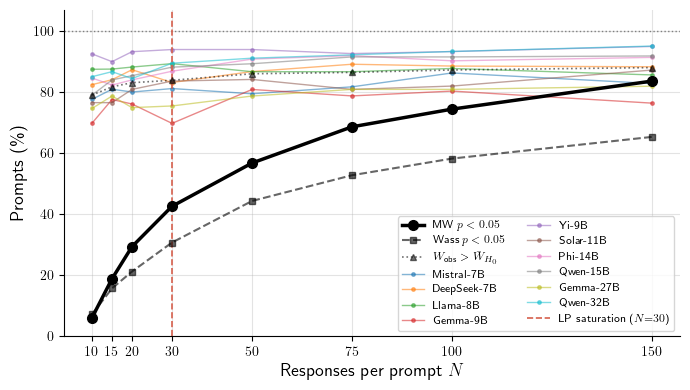

In [11]:
cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(7, 4))

# global bold curves
ax.plot(
    global_frac["N"],
    global_frac["frac_sig_mw"] * 100,
    color="black", lw=2.5, marker="o", ms=7, zorder=5,
    label="MW $p<0.05$",
)
ax.plot(
    global_frac["N"],
    global_frac["frac_sig_wass"] * 100,
    color="black", lw=1.5, marker="s", ms=5, zorder=4,
    ls="--", alpha=0.6,
    label="Wass $p<0.05$",
)
ax.plot(
    global_frac["N"],
    global_frac["frac_above_fixed"] * 100,
    color="black", lw=1.2, marker="^", ms=5, zorder=4,
    ls=":", alpha=0.55,
    label=r"$W_{\text{obs}} > \bar W_{H_0}$",
)

# per-model faint curves (W_obs > null mean — less noisy at small N)
for i, mid in enumerate(model_order):
    df_m = model_frac[model_frac["model_id"] == mid]
    if df_m.empty:
        continue
    ax.plot(
        df_m["N"],
        df_m["frac_above_model"] * 100,
        color=cmap(i % cmap.N), lw=1.0, alpha=0.55,
        marker=".", ms=5, label=model_names[mid],
    )

ax.axhline(100, color="gray", ls=":", lw=1.0)
ax.axvline(30, color="#d6604d", ls="--", lw=1.2,
           label="LP saturation ($N{=}30$)")

ax.set_xlabel("Responses per prompt $N$", fontsize=13)
ax.set_ylabel(r"Prompts (\%)", fontsize=13)
ax.set_xticks(N_values)
ax.set_ylim(0, 107)
ax.grid(True, alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, ncols=2, loc="lower right")

plt.tight_layout()
fig.savefig(f"{figures_dir}/SA_sig_fraction_vs_N.pdf", bbox_inches="tight")
plt.show()

## Separability ratio vs N (original and Fisher space)

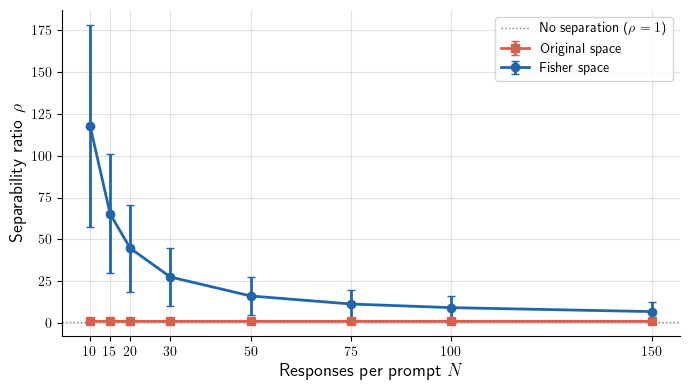

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(
    global_frac["N"],
    global_frac["sep_mean"],
    yerr  = global_frac["sep_std"],
    color = "#d6604d", lw=2, marker="s", ms=6, capsize=3,
    label = "Original space",
)

ax.errorbar(
    global_frac["N"],
    global_frac["sep_z_mean"],
    yerr  = global_frac["sep_z_std"],
    color = "#2166ac", lw=2, marker="o", ms=6, capsize=3,
    label = "Fisher space",
)

ax.axhline(1.0, color="gray", ls=":", lw=1.0, label="No separation ($\\rho=1$)")
ax.set_xlabel("Responses per prompt $N$", fontsize=13)
ax.set_ylabel(r"Separability ratio $\rho$", fontsize=13)
ax.set_xticks(N_values)
ax.grid(True, alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10)

plt.tight_layout()
fig.savefig(f"{figures_dir}/SA_separability_vs_N.pdf", bbox_inches="tight")
plt.show()

## $W_{\text{obs}}$ vs null distribution at selected N

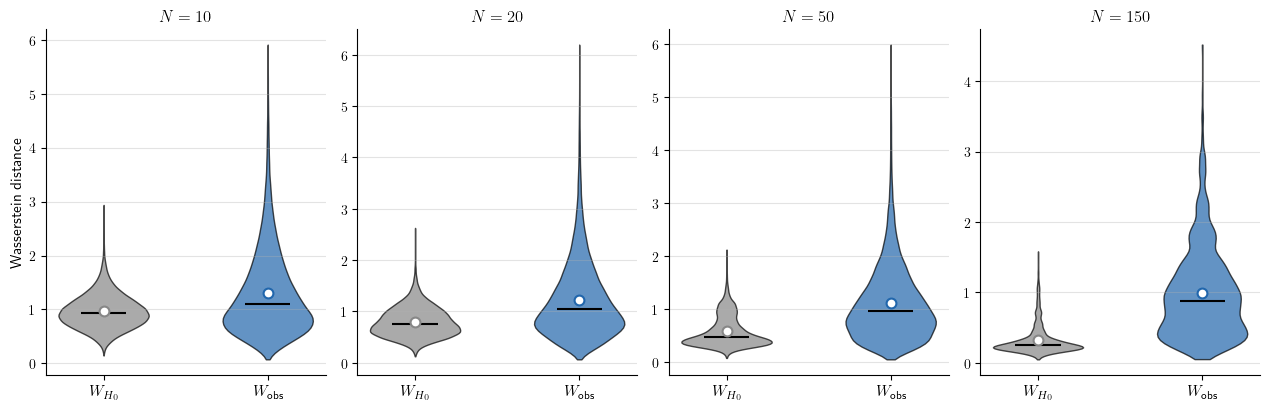

In [13]:
SELECTED_N = [10, 20, 50, 150]

fig, axes = plt.subplots(
    1, len(SELECTED_N), figsize=(3.2 * len(SELECTED_N), 4.2), sharey=False
)

for ax, N in zip(axes, SELECTED_N):
    sub = results_sa[results_sa["N"] == N]
    if sub.empty:
        ax.set_title(f"$N={N}$ (no data)")
        continue

    data_null = sub["W_null_mean"].values
    data_obs  = sub["W_obs"].values

    vp = ax.violinplot(
        [data_null, data_obs],
        positions=[1, 2], vert=True, widths=0.55,
        showmeans=False, showextrema=False, showmedians=True,
    )
    colors_vp = ["#878787", "#2166ac"]
    for body, c in zip(vp["bodies"], colors_vp):
        body.set_facecolor(c); body.set_edgecolor("black"); body.set_alpha(0.70)
    vp["cmedians"].set_color("black"); vp["cmedians"].set_linewidth(1.5)

    for pos, vals, c in zip([1, 2], [data_null, data_obs], colors_vp):
        ax.scatter(pos, vals.mean(), color="white", edgecolors=c,
                   zorder=5, s=50, linewidths=1.5)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([r"$W_{H_0}$", r"$W_{\text{obs}}$"], fontsize=11)
    ax.set_title(f"$N = {N}$", fontsize=12)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Wasserstein distance", fontsize=11)
plt.tight_layout()
fig.savefig(f"{figures_dir}/SA_wass_violin_selected_N.pdf", bbox_inches="tight")
plt.show()

## Per-model heatmap of fraction significant (fixed denominator)

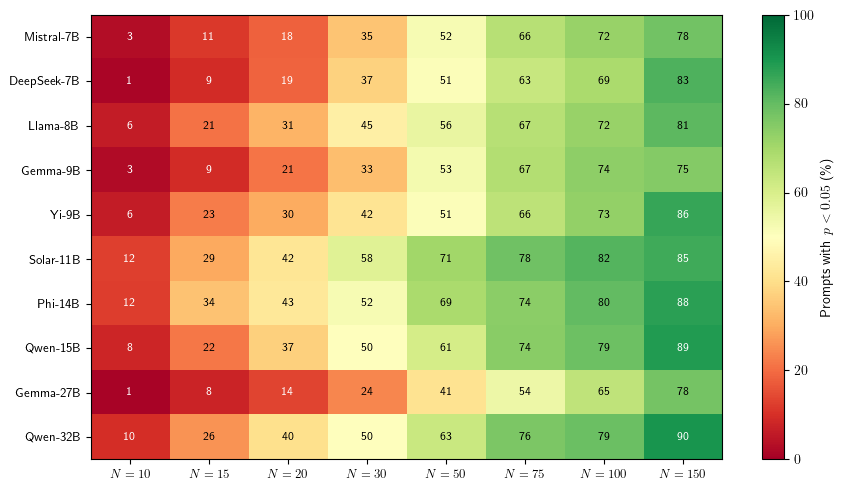

In [14]:
pivot = model_frac.pivot(
    index="model_id", columns="N", values="frac_sig_mw"
) * 100

pivot = pivot.reindex(index=model_order)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"$N={n}$" for n in pivot.columns], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([model_names[m] for m in pivot.index], fontsize=9)

for (i, j), val in np.ndenumerate(pivot.values):
    if not np.isnan(val):
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=8,
                color="black" if 20 < val < 85 else "white")

plt.colorbar(im, ax=ax, label=r"Prompts with $p < 0.05$ (\%)")
plt.tight_layout()
fig.savefig(f"{figures_dir}/SA_sig_heatmap_model_N.pdf", bbox_inches="tight")
plt.show()

## LaTeX table — Fig. 7 (and 10) 

All percentages use the fixed denominator $M = N_{\text{valid}}$.
The table reports both the Wasserstein significance rate and the separability
ratio in both spaces, so you can choose what to highlight in the rebuttal.

In [15]:
table_rows = []
for _, r in global_frac.iterrows():
    table_rows.append({
        "$N$":                         int(r["N"]),
        "Tested":                      int(r["n_tested"]),
        r"MW Sig.~(\%)":             ap.fmt_pct(r["frac_sig_mw"]),
        r"Wass Sig.~(\%)":           ap.fmt_pct(r["frac_sig_wass"]),
        r"$W_{\\text{obs}}>\\bar W_{H_0}$ (\%)": ap.fmt_pct(r["frac_above_fixed"]),
        r"$\bar W_{\text{obs}}$":    ap.fmt(r["W_obs_mean"],  r["W_obs_std"], prec=3),
        r"$\bar W_{H_0}$":            ap.fmt(r["W_null_mean"], r["W_null_std"], prec=3),
        r"$\bar\rho$":               ap.fmt(r["sep_mean"],    r["sep_std"], prec=3),
        r"$\bar\rho_z$":             ap.fmt(r["sep_z_mean"],  r["sep_z_std"], prec=3),
    })

table_df = pd.DataFrame(table_rows)

latex_table = table_df.to_latex(
    index         = False,
    escape        = False,
    column_format = "rrrrrccccc",
    caption       = (
        r"Structural separability ablation. "
        r"Responses are subsampled to $N$ per prompt (natural class ratio; "
        r"accepted only if $n_G \geq 2$ and $n_H \geq 2$). "
        r"\emph{MW Sig.} is the fraction of prompts with Mann-Whitney "
        r"$p < 0.05$ on $D_{GG}$ vs $D_{HH}$ (same test as the violin plots). "
        r"\emph{Wass Sig.} uses the Wasserstein permutation test. "
        r"Both use the per-$N$ fixed denominator $M = |\{(m,p): n_{\text{total}} \geq N\}|$."
    ),
    label = "tab:structural_ablation",
)
print(latex_table)

\begin{table}
\caption{Structural separability ablation. Responses are subsampled to $N$ per prompt (natural class ratio; accepted only if $n_G \geq 2$ and $n_H \geq 2$). \emph{MW Sig.} is the fraction of prompts with Mann-Whitney $p < 0.05$ on $D_{GG}$ vs $D_{HH}$ (same test as the violin plots). \emph{Wass Sig.} uses the Wasserstein permutation test. Both use the per-$N$ fixed denominator $M = |\{(m,p): n_{\text{total}} \geq N\}|$.}
\label{tab:structural_ablation}
\begin{tabular}{rrrrrccccc}
\toprule
$N$ & Tested & MW Sig.~(\%) & Wass Sig.~(\%) & $W_{\\text{obs}}>\\bar W_{H_0}$ (\%) & $\bar W_{\text{obs}}$ & $\bar W_{H_0}$ & $\bar\rho$ & $\bar\rho_z$ \\
\midrule
10 & 1740 & 6.1 & 7.3 & 79.1 & 1.326 (0.543) & 0.979 (0.194) & 1.141 (0.140) & 117.687 (60.419) \\
15 & 1757 & 18.9 & 15.8 & 81.8 & 1.282 (0.547) & 0.887 (0.206) & 1.141 (0.136) & 65.229 (35.516) \\
20 & 1774 & 29.4 & 21.3 & 83.2 & 1.239 (0.548) & 0.816 (0.221) & 1.138 (0.134) & 44.766 (25.927) \\
30 & 1777 & 42.7 & 30.8 & 84